In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU')
from tensorflow.keras.datasets import mnist

import hmc
import func

In [3]:
def preprocess(X):
    X = func.downsize_mnist(X)
    X = X.reshape(len(X), -1)
    X, _ = func.normalize(X)
    return X

In [4]:
# load, downsize and normalize the dataset
(Xtrain, _), (Xtest, _) = mnist.load_data()
Xtrain = preprocess(Xtrain)
Xtrain = Xtrain[np.random.RandomState(1).permutation(len(Xtrain))].T
Xtest = preprocess(Xtest).T


Xtrain = tf.convert_to_tensor(Xtrain, dtype=tf.float32)
Xtest = tf.convert_to_tensor(Xtest, dtype=tf.float32)

I0000 00:00:1760697638.236306 2754556 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14242 MB memory:  -> device: 1, name: NVIDIA RTX A4000, pci bus id: 0000:65:00.0, compute capability: 8.6


In [6]:
d = 144
gamma = 0.5
alpha = 5/6
Delta = 0.1

k = int(gamma*d)
n = int(alpha*d**2)

vlaw = 'gaussd'
sig = lambda x: tf.nn.tanh(2*x)

X = Xtrain[:,:n]


In [7]:
params = {'step_size': 0.01,
          'num_leapfrog_steps': 10,
          'num_adaptation_steps': 2000,
          'num_post_adapt_steps': 0}


W0, Y, v = hmc.data_generate(d, k, n, Delta, sig, vlaw, X)
Ws_info = hmc.hmc(params, W0, X, Y, v, gamma, alpha, Delta, sig, show_acceptance_rate=True, show_adaptation_steps=True)
test_info =  hmc.test_error(Ws_info, W0, v, sig, Xtest)

Acceptance rate: 0.6905


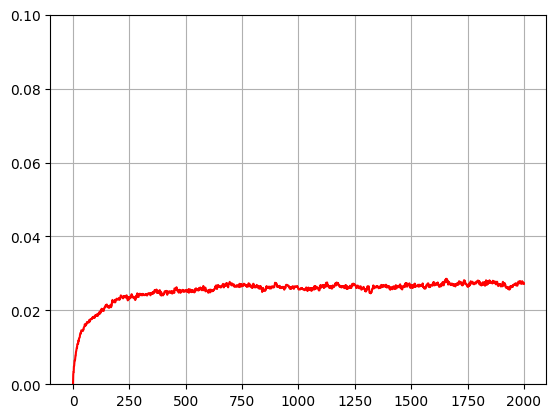

In [8]:
plt.plot(test_info, color='red')
plt.ylim(0, 0.1)
plt.grid()
plt.show()

In [9]:
np.mean(test_info[-500:])

np.float32(0.027074765)